In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries loaded successfully")

Libraries loaded successfully


In [4]:
from google.colab import files

uploaded = files.upload()

Saving superstore_final_dataset (1).csv to superstore_final_dataset (1).csv


In [5]:
df = pd.read_csv("superstore_final_dataset (1).csv", encoding='latin1')

df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [6]:
print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (9800, 18)

Data types:
Row_ID             int64
Order_ID          object
Order_Date        object
Ship_Date         object
Ship_Mode         object
Customer_ID       object
Customer_Name     object
Segment           object
Country           object
City              object
State             object
Postal_Code      float64
Region            object
Product_ID        object
Category          object
Sub_Category      object
Product_Name      object
Sales            float64
dtype: object

Missing values:
Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64


In [7]:
# Data cleaning

# Convert date columns
df["Order_Date"] = pd.to_datetime(df["Order_Date"], dayfirst=True)
df["Ship_Date"] = pd.to_datetime(df["Ship_Date"], dayfirst=True)

# Fill missing postal codes
df["Postal_Code"] = df["Postal_Code"].fillna(0)

# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Duplicate rows: 0

Missing values after cleaning:
Row_ID           0
Order_ID         0
Order_Date       0
Ship_Date        0
Ship_Mode        0
Customer_ID      0
Customer_Name    0
Segment          0
Country          0
City             0
State            0
Postal_Code      0
Region           0
Product_ID       0
Category         0
Sub_Category     0
Product_Name     0
Sales            0
dtype: int64


In [8]:
# KPI calculations

total_revenue = df["Sales"].sum()

average_order_value = df["Sales"].mean()

total_orders = df["Order_ID"].nunique()

print("Total Revenue: ", round(total_revenue,2))
print("Average Order Value: ", round(average_order_value,2))
print("Total Orders: ", total_orders)

Total Revenue:  2261536.78
Average Order Value:  230.77
Total Orders:  4922


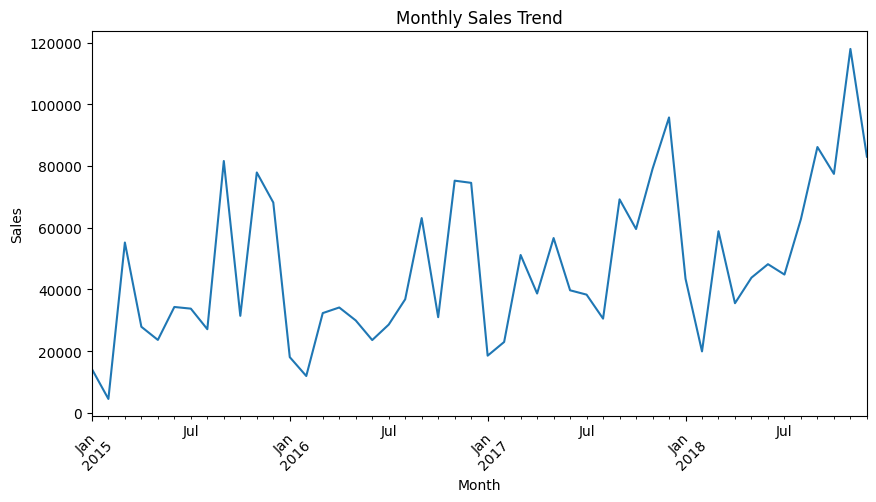

In [9]:
# Sales trend over time

monthly_sales = df.groupby(df["Order_Date"].dt.to_period("M"))["Sales"].sum()

monthly_sales.plot(figsize=(10,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

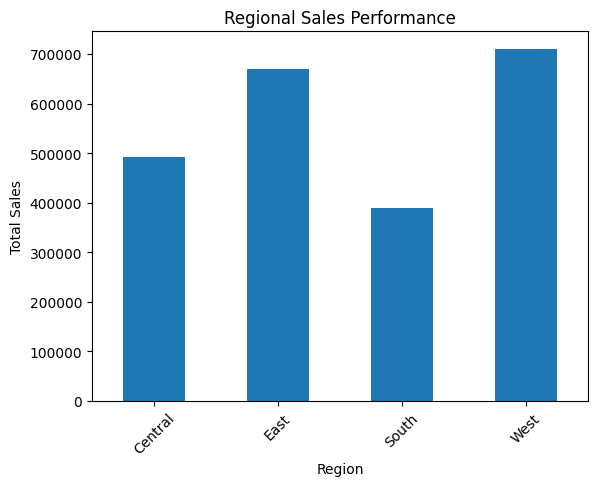

In [10]:
# Regional sales performance

region_sales = df.groupby("Region")["Sales"].sum()

region_sales.plot(kind="bar")

plt.title("Regional Sales Performance")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

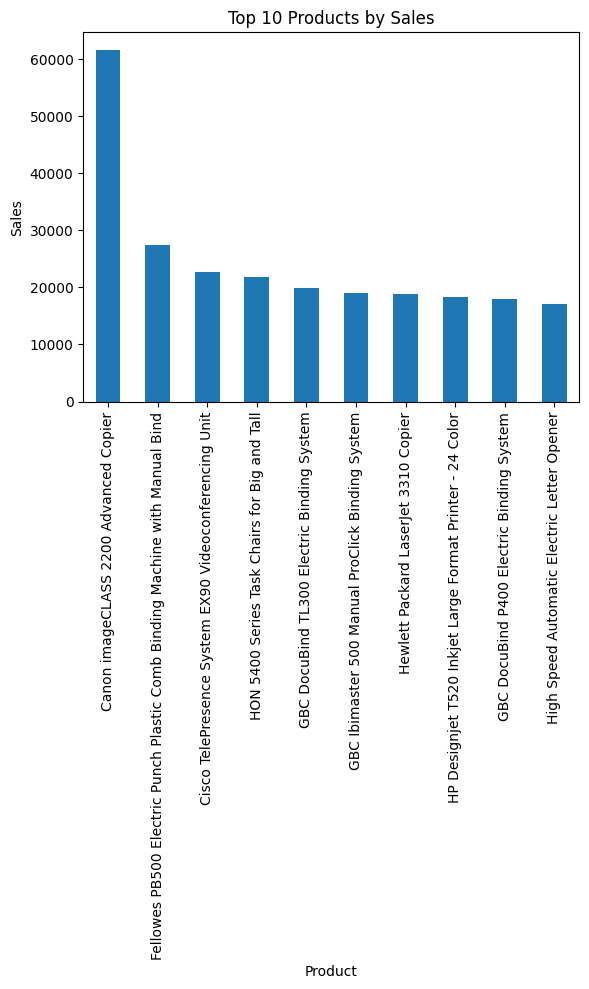

In [11]:
# Top 10 products by sales

top_products = df.groupby("Product_Name")["Sales"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="bar")

plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")

plt.xticks(rotation=90)

plt.show()

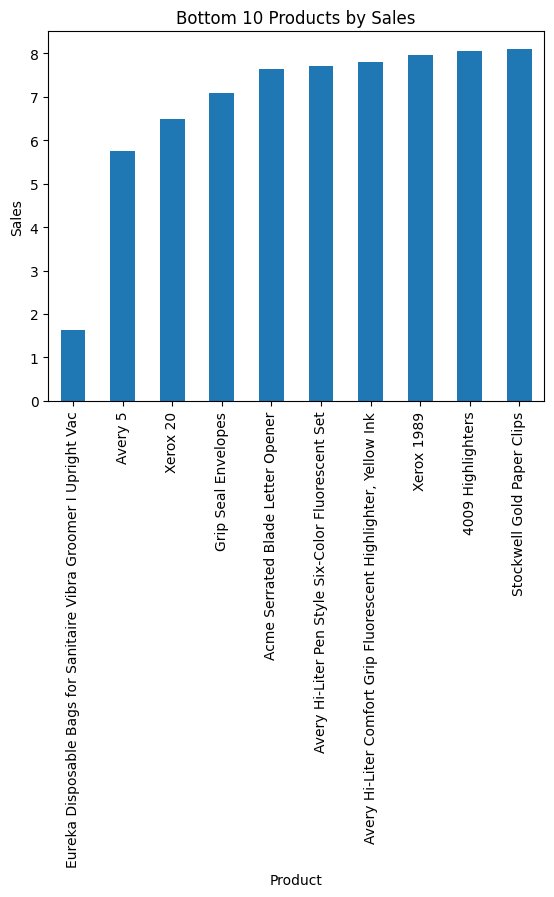

In [12]:
# Bottom 10 products by sales

bottom_products = df.groupby("Product_Name")["Sales"].sum().sort_values().head(10)

bottom_products.plot(kind="bar")

plt.title("Bottom 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")

plt.xticks(rotation=90)

plt.show()

**Actionable Recommendations for Alfido Tech**
Focus marketing efforts on high-performing regions such as West and analyze successful strategies that can be implemented in weaker regions.
Improve sales performance in low-performing regions through targeted campaigns, customer engagement programs, and promotional offers.
Prioritize top-selling products by maintaining sufficient inventory and increasing promotional activities.
Review low-performing products and optimize pricing strategies or reduce inventory for products with consistently low sales.
Use seasonal sales patterns for better demand forecasting and inventory planning.

**Executive Summary**

Sales analysis was conducted using the Superstore dataset to evaluate performance across regions, products, and time periods. The analysis showed an overall growth trend in sales with noticeable seasonal fluctuations. The West region generated the highest sales, while the South region showed comparatively weaker performance. Product-level analysis identified key revenue-generating products as well as low-performing items that may require business attention. The findings indicate opportunities for improving regional balance, optimizing inventory management, and strengthening marketing strategies. Overall, the business demonstrates positive growth potential with scope for further performance improvement.